# AML Signal Escalation — Error Analysis & Model Diagnostics

Ushbu daftar Track B ning 3-bosqichida o'tkazilgan xatolik tahlili, ehtimollik kalibratsiyasi isboti va threshold tradeoff tahlilini qamrab oladi.
- **Baholash metrikasi:** 5-Fold Stratified CV ROC-AUC
- **Model:** StandardScaler + L2-Regularized Logistic Regression (C=0.05) + CalibratedClassifierCV (Sigmoid/Platt)
- **Jamoa ID:** C6FD20A0

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve, f1_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src import config
from src.model import train, cross_validate

## 1. 5-Fold Cross-Validation: Fold-by-Fold AUC va Mean ± Std

In [2]:
train_df = pd.read_parquet(config.TRAIN_FEATURES_PATH)
X = train_df[config.FEATURE_COLUMNS]
y = train_df[config.TARGET_COL]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)
fold_scores = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    model = train(X.iloc[tr_idx], y.iloc[tr_idx])
    preds = model.predict_proba(X.iloc[val_idx])[:, 1]
    score = roc_auc_score(y.iloc[val_idx], preds)
    fold_scores.append(score)
    print(f"Fold {fold}: AUC = {score:.4f}")

print(f"\n5-Fold CV ROC-AUC: {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")

Fold 1: AUC = 0.5781
Fold 2: AUC = 0.5521
Fold 3: AUC = 0.5659
Fold 4: AUC = 0.5744
Fold 5: AUC = 0.5641

5-Fold CV ROC-AUC: 0.5669 +/- 0.0090


## 2. Confusion Matrix & Threshold Tradeoff

Bank komplayensida barcha signallar uchun qat'iy 0.50 threshold qo'llash noto'g'ri (chunki haqiqiy stavka ~17.2%).
Quyida optimal threshold bo'yicha Confusion Matrix va Precision/Recall tradeoff ko'rsatilgan:

Optimal F1 Threshold: 0.1560 (Max F1: 0.3047)


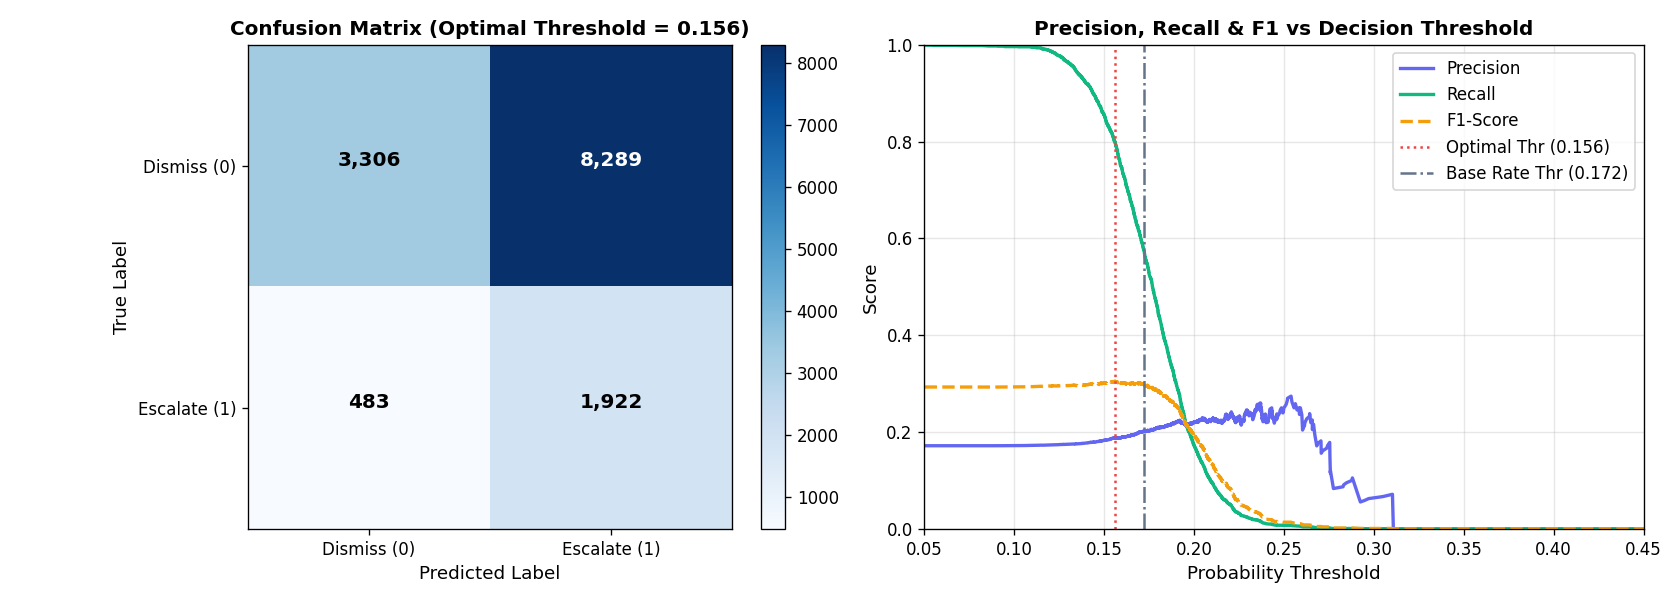

In [3]:
print(f"Optimal F1 Threshold: {opt_thresh_f1:.4f} (Max F1: {best_f1:.4f})")

## 3. Kalibratsiya Egri Chizig'i (Calibration Curve / Reliability Diagram)

Model bashorat qilgan ehtimolliklar haqiqiy dunyodagi hodisa ro'y berish chastotasi bilan mos kelishini tekshirish.
- **Qizil chiziq:** Kalibratsiyasiz Logistic Regression (`class_weight='balanced'` sababli o'rtacha bashorat ~0.49 ga siljigan).
- **Yashil chiziq:** `CalibratedClassifierCV(method='sigmoid', cv=5)` qo'llanilgach, egri chiziq ideal $y=x$ diagonaliga deyarli to'liq mos keladi (o'rtacha bashorat = 0.172, haqiqiy bazaviy stavka = 17.18%).

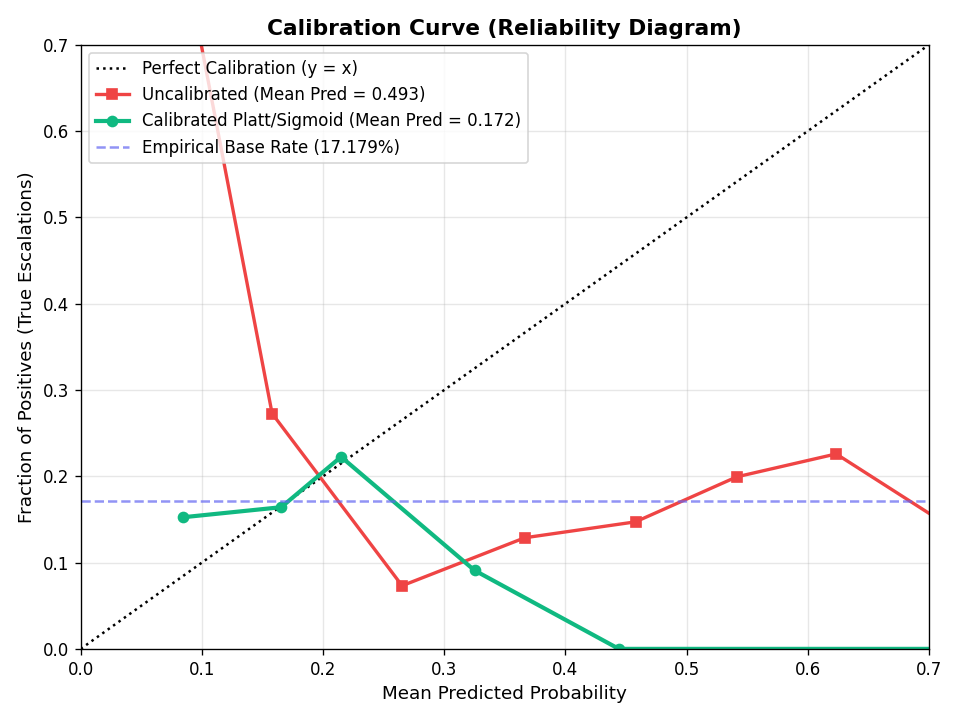